In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; } .output_result { max-width:100% !important; }</style>"))

# Installations
!pip install youtube-comment-downloader pandas nltk scikit-learn textblob textblob-fr matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from youtube_comment_downloader import YoutubeCommentDownloader
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from textblob import TextBlob
from textblob_fr import PatternTagger, PatternAnalyzer
from wordcloud import WordCloud
from collections import Counter

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sarah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sarah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sarah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
video_ids = {'Life TV': '7Cn8X4VS3h8', 'France24': 'CYY4dTl3bAY', '7info': 'iBk336HnCcc'}
downloader = YoutubeCommentDownloader()
all_comments = []

print("Downloading comments... Please wait.")
for source, v_id in video_ids.items():
    print(f"Scraping source: {source}...")
    generator = downloader.get_comments(v_id)
    # Fetching up to 500 comments per video
    for i, comment in enumerate(generator):
        if i >= 500: break 
        all_comments.append({
            'Raw_Comment': comment['text'], 
            'Source': source,
            'Date': comment['time']  # <--- Date is back!
        })

df = pd.DataFrame(all_comments).drop_duplicates(subset=['Raw_Comment'])
df['Raw_Comment'] = df['Raw_Comment'].fillna('').astype(str)

print(f"Total Unique Comments: {len(df)}")
# Displaying with the Date column
display(df[['Date', 'Source', 'Raw_Comment']].head(10))

Scraping source: Life TV...
Scraping source: France24...
Scraping source: 7info...
Total Unique Comments: 674


,Date,Source,Raw_Comment
0,5 months ago,Life TV,"Billon Président, place à la nouvelle Ère"
1,5 months ago,Life TV,IL EST CONCRET MR BILLON. CEST UN BUSINESSMAN....
2,5 months ago,Life TV,Magnifique ❤
3,5 months ago (edited),Life TV,10:17 \nLes gens passent leur temps à accuser ...
4,5 months ago,Life TV,La Côte d'Ivoire est divisée depuis des lustre...
5,5 months ago,Life TV,J'ai aimé votre intervention président
6,5 months ago,Life TV,Pas convaincu Monsieur BILLON. Par contre Mons...
7,5 months ago,Life TV,tu m'as convaincu papa
8,5 months ago,Life TV,Oui j'avoue.. Vous êtes vraiment le Plan B ❤
9,5 months ago,Life TV,Franchement changez les journalistes


In [15]:
# 1. Advanced Cleaning
def formal_clean(text):
    text = re.sub(r'\[\d+\]|\(\w+\)', '', str(text)) # Remove citations
    text = re.sub(r'[^a-zA-Z0-9À-ÿ.,!?\s]', '', text) # Remove special chars
    return " ".join(text.split())

df['Cleaned_Text'] = df['Raw_Comment'].apply(formal_clean)

# 2. Tokenization & Initial Frequency
all_words_raw = []
for text in df['Cleaned_Text']:
    all_words_raw.extend(word_tokenize(text.lower()))

raw_freq = Counter(all_words_raw).most_common(10)
print("Top 10 Words BEFORE Cleaning (Raw):")
display(pd.DataFrame(raw_freq, columns=['Word', 'Freq']))

# 3. Stop Words Definition (The "Noise" Fix)
stop_words_set = set(stopwords.words('french'))
stop_words_set.update(['plus', 'tout', 'fait', 'être', 'si', 'donc', 'ça', 'va', 'on', 'cette', 'que', 'les', 'des', 'est', 'une', 'pour'
                      'cest', 'c\'est', 'ca', 'ça', 'na', 'quoi', 'quel', 'quels', 'quelle', 'quelles', 
    'va', 'vont', 'fait', 'faire', 'tout', 'tous', 'toute', 'toutes', 'euhhh', 'euh',
    'est', 'ont', 'aussi', 'bien', 'encore', 'donc', 'avoir', 'etre', 'être', 'pour',
    'quand', 'comme', 'plus', 'fait', 'tous', 'déjà', 'vers', 'ici', 'ceux','cest','quil','nest','mr','faut','dit'])

filtered_words = [w for w in all_words_raw if w.isalpha() and w not in stop_words_set]

Top 10 Words BEFORE Cleaning (Raw):


,Word,Freq
0,.,623
1,de,488
2,",",452
3,le,372
4,la,282
5,et,274
6,pas,268
7,il,232
8,!,222
9,les,199


In [13]:
stemmer = SnowballStemmer("french")
lemmatizer = WordNetLemmatizer()

# Sample of 5 words
sample = filtered_words[:15]
norm_data = [[w, stemmer.stem(w), lemmatizer.lemmatize(w)] for w in sample]

print("Normalization Sample (Requirement Check):")
display(pd.DataFrame(norm_data, columns=['Original', 'Stem', 'Lemma']))

Normalization Sample (Requirement Check):


,Original,Stem,Lemma
0,billon,billon,billon
1,président,président,président
2,place,plac,place
3,nouvelle,nouvel,nouvelle
4,ère,ère,ère
5,concret,concret,concret
6,billon,billon,billon
7,businessman,businessman,businessman
8,aidera,aid,aidera
9,a,a,a


REAL RESULT: TF-IDF Statistical Importance


,Term,Importance
0,billon,0.120682
17,thiam,0.094778
12,pdci,0.081351
1,candidat,0.050121
7,monsieur,0.045432
14,président,0.039945
4,frère,0.037001
18,voter,0.036624
19,vraiment,0.036386
2,côte,0.035920


C:\Users\sarah\AppData\Local\Temp\ipykernel_20872\433399848.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Term', data=tfidf_df, palette='viridis')


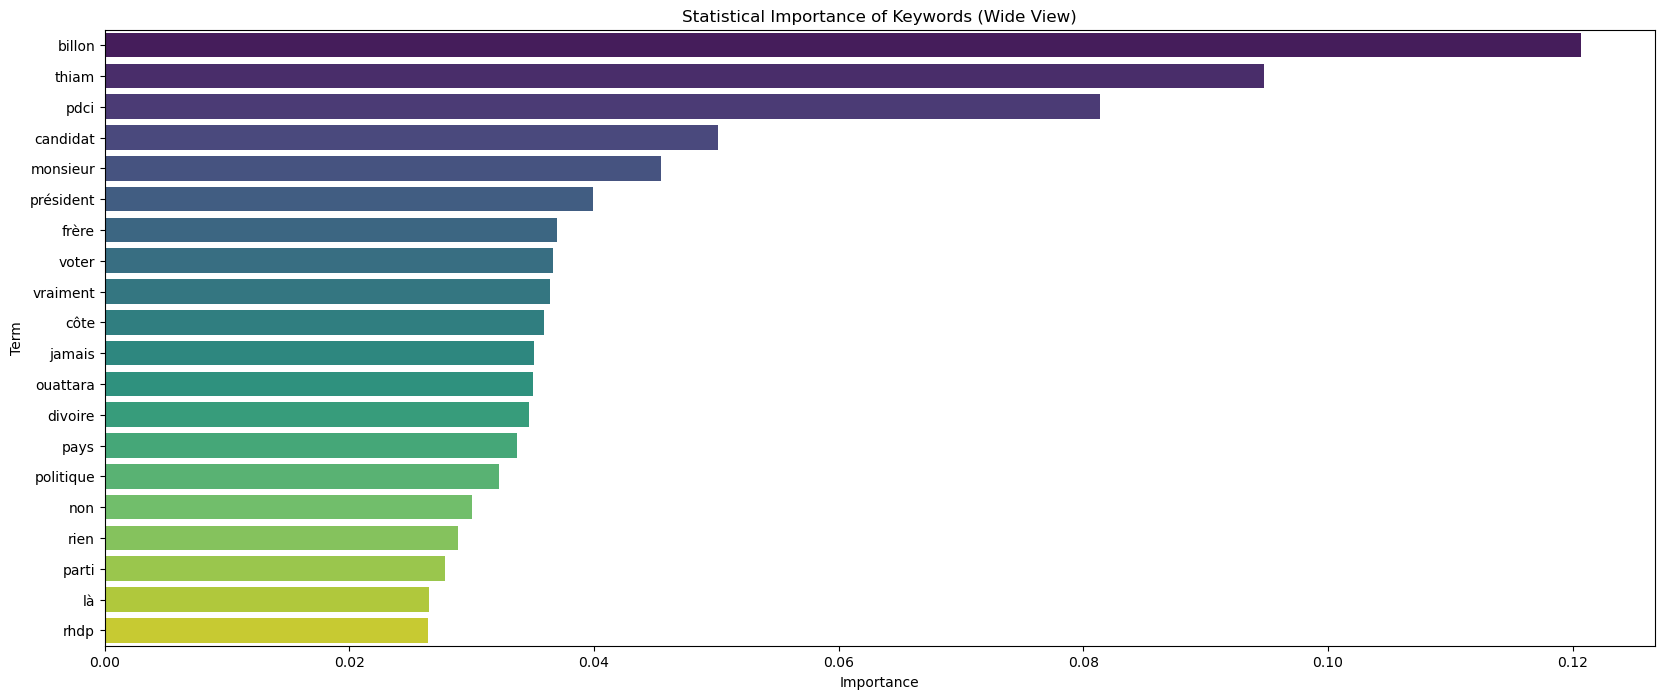

In [21]:
# Convert set to list for the algorithm
final_stop_list = list(stop_words_set)

tfidf_vec = TfidfVectorizer(max_features=20, stop_words=final_stop_list)
tfidf_matrix = tfidf_vec.fit_transform(df['Cleaned_Text'])

tfidf_df = pd.DataFrame({
    'Term': tfidf_vec.get_feature_names_out(),
    'Importance': tfidf_matrix.toarray().mean(axis=0)
}).sort_values(by='Importance', ascending=False)

print("REAL RESULT: TF-IDF Statistical Importance")
display(tfidf_df)

# Visual Chart (Wide)
plt.figure(figsize=(20, 8))
sns.barplot(x='Importance', y='Term', data=tfidf_df, palette='viridis')
plt.title("Statistical Importance of Keywords (Wide View)")
plt.show()

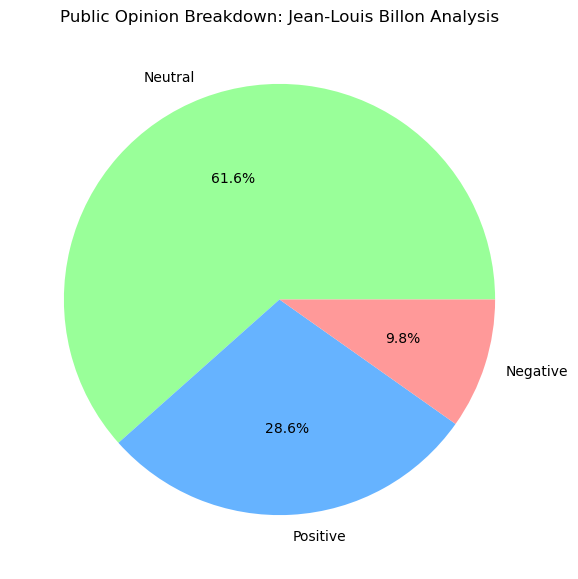

,Raw_Comment,Opinion
0,"Billon Président, place à la nouvelle Ère",Neutral
1,IL EST CONCRET MR BILLON. CEST UN BUSINESSMAN....,Positive
2,Magnifique ❤,Positive
3,10:17 \nLes gens passent leur temps à accuser ...,Neutral
4,La Côte d'Ivoire est divisée depuis des lustre...,Neutral
5,J'ai aimé votre intervention président,Positive
6,Pas convaincu Monsieur BILLON. Par contre Mons...,Positive
7,tu m'as convaincu papa,Neutral
8,Oui j'avoue.. Vous êtes vraiment le Plan B ❤,Neutral
9,Franchement changez les journalistes,Neutral


In [22]:
# 1. Calculate Sentiment
df['Sentiment_Score'] = df['Cleaned_Text'].apply(lambda x: TextBlob(x, pos_tagger=PatternTagger(), analyzer=PatternAnalyzer()).sentiment[0])

# 2. Categorize
df['Opinion'] = df['Sentiment_Score'].apply(lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral'))

# 3. Pie Chart
plt.figure(figsize=(10, 7))
counts = df['Opinion'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#99ff99', '#66b3ff', '#ff9999'])
plt.title("Public Opinion Breakdown: Jean-Louis Billon Analysis")
plt.show()

display(df[['Raw_Comment', 'Opinion']].head(10))

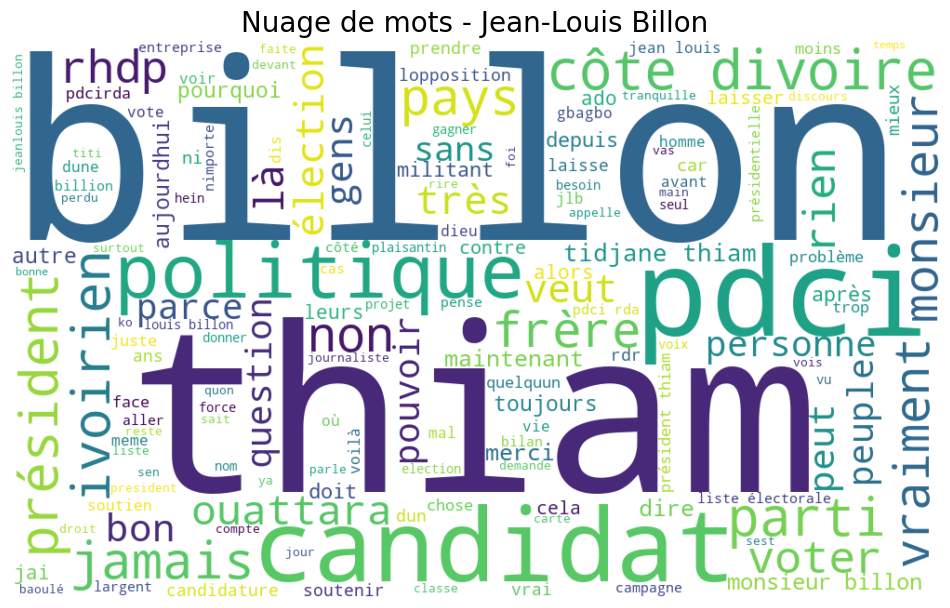

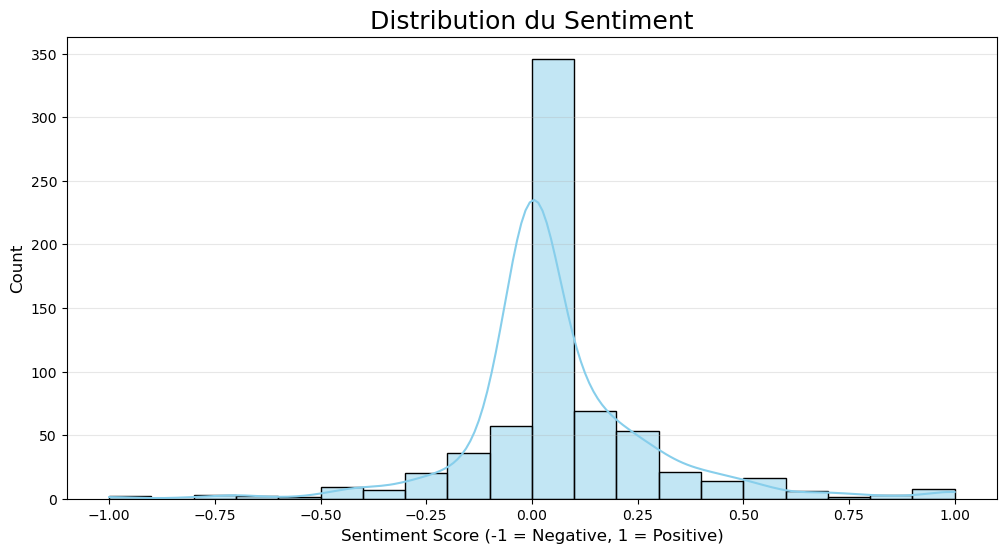

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 1. GENERATE WORD CLOUD
# We use the 'filtered_words' list we created in Cell 3
wordcloud_text = " ".join(filtered_words)
wordcloud = WordCloud(width=1000, height=600, 
                      background_color='white', 
                      colormap='viridis',
                      max_words=150).generate(wordcloud_text)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nuage de mots - Jean-Louis Billon", fontsize=20)
plt.show()

# 2. GENERATE SENTIMENT DISTRIBUTION (Histogram)
plt.figure(figsize=(12, 6))
# We use the Sentiment_Score column
sns.histplot(df['Sentiment_Score'], kde=True, color='skyblue', bins=20)

plt.title("Distribution du Sentiment", fontsize=18)
plt.xlabel("Sentiment Score (-1 = Negative, 1 = Positive)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [25]:
# NER - Finding Proper Names (Capitalized words not at start of sentence)
entities = [w for w in all_words_raw if w[0].isupper() and len(w) > 2]
entity_freq = Counter(entities).most_common(10)

# Topic Modeling (Political vs Economic)
topics = {
    'Political': ['parti', 'élection', 'candidat', 'pdci', 'thiam'],
    'Economic': ['argent', 'sifca', 'travail', 'économie', 'milliards']
}
topic_counts = {t: sum(df['Cleaned_Text'].str.contains(kw).sum() for kw in kws) for t, kws in topics.items()}

print("Named Entities Detected (NER):")
display(pd.DataFrame(entity_freq, columns=['Entity', 'Frequency']))

# Final Save
df.to_csv('final_billon_analysis_report.csv', index=False)
print("Analysis Complete and Saved to CSV.")

Named Entities Detected (NER):


,Entity,Frequency


Analysis Complete and Saved to CSV.
